# Sistem Rekomendasi Film Berbasis Deep Learning (NCF) untuk Memprediksi Rating

**Baca dan Olah Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

df = pd.merge(ratings, movies, on="movieId")


**Distribusi Rating Secara Umum**

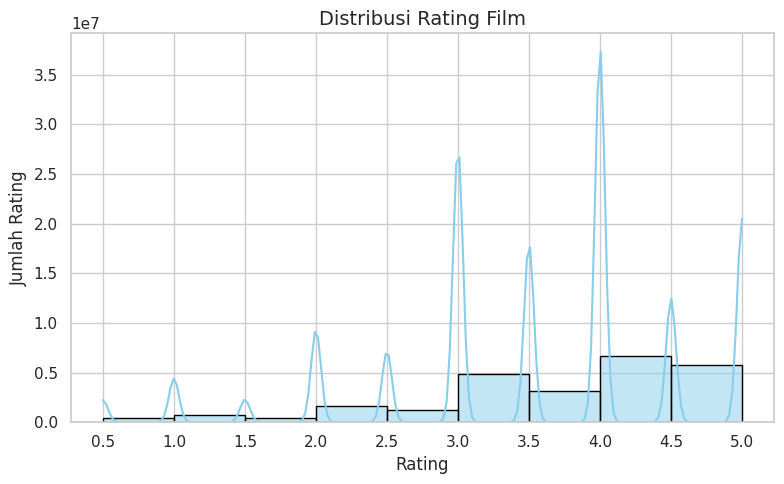

In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=ratings,
    x='rating',
    bins=9,
    kde=True,
    color="skyblue",
    edgecolor='black'
)
plt.title("Distribusi Rating Film", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Jumlah Rating", fontsize=12)
plt.xticks(ticks=sorted(ratings['rating'].unique()))  # agar label rating 0.5, 1.0, 1.5, ..., 5.0 terlihat
plt.tight_layout()
plt.show()


**Visualisasi Jumlah Film Berdasarkan Genre**

/tmp/ipython-input-3-1775933596.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


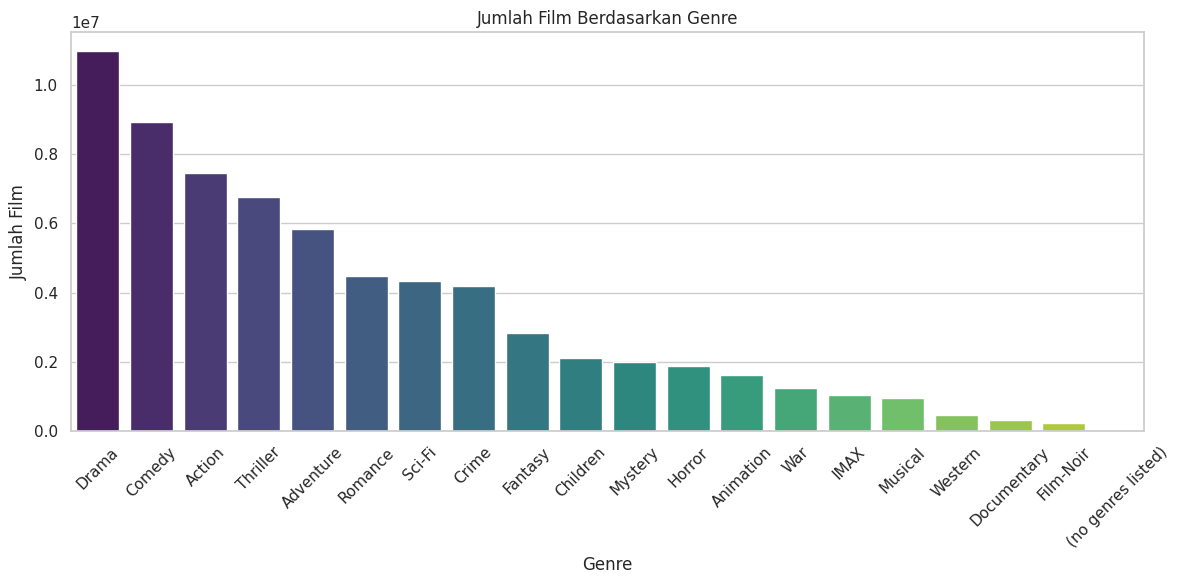

In [3]:
# Pecah genre yang dipisah oleh '|'
all_genres = df['genres'].str.split('|').explode()

# Hitung jumlah film per genre
genre_counts = all_genres.value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Jumlah Film Berdasarkan Genre")
plt.xlabel("Genre")
plt.ylabel("Jumlah Film")
plt.tight_layout()
plt.show()


**Aktivitas Pengguna Berdasarkan Jumlah Rating yang Diberikan**

/tmp/ipython-input-7-3745062380.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_activity.index.astype(str), y=user_activity.values, palette="coolwarm")


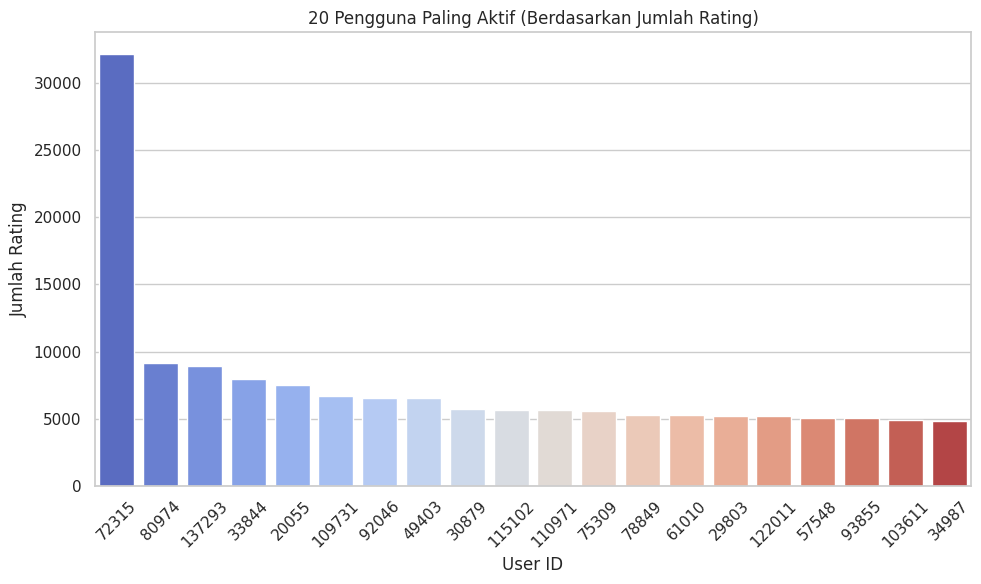

In [7]:
# Hitung jumlah rating per user
user_activity = ratings['userId'].value_counts().sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=user_activity.index.astype(str), y=user_activity.values, palette="coolwarm")
plt.title("20 Pengguna Paling Aktif (Berdasarkan Jumlah Rating)")
plt.xlabel("User ID")
plt.ylabel("Jumlah Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Encode userId dan movieId ke angka indeks**

In [ ]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
movie_enc = LabelEncoder()

ratings['user'] = user_enc.fit_transform(ratings['userId'])
ratings['movie'] = movie_enc.fit_transform(ratings['movieId'])


**Melihat Ratings**

In [ ]:
ratings[['userId', 'user', 'movieId', 'movie']].head()


,userId,user,movieId,movie
0,1,0,296,292
1,1,0,306,302
2,1,0,307,303
3,1,0,665,653
4,1,0,899,875


**Normalisasi rating**

In [ ]:
ratings['rating'] = ratings['rating'].astype('float32')


**Split Data Train dan Test**

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings[['user', 'movie', 'rating']],
    test_size=0.2,
    random_state=42
)


**Membangun Model Deep Learning (Rekomendasi Film)**

**Menggunkan Model Neural Collaborative Filtering**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
n_users = ratings['user'].nunique()
n_movies = ratings['movie'].nunique()


**Bangun Model Rekomendasi**

In [ ]:
class RecommenderNet(nn.Module):
    def __init__(self, n_users, n_movies, embedding_size=50):
        super(RecommenderNet, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_size)
        self.movie_embedding = nn.Embedding(n_movies, embedding_size)

        self.fc = nn.Sequential(
            nn.Linear(embedding_size * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, user, movie):
        user_emb = self.user_embedding(user)
        movie_emb = self.movie_embedding(movie)
        x = torch.cat([user_emb, movie_emb], dim=1)
        out = self.fc(x)
        return out


**Siapkan DataLoader untuk Pelatihan**


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Ubah ke tensor
train_dataset = TensorDataset(
    torch.tensor(train['user'].values, dtype=torch.long),
    torch.tensor(train['movie'].values, dtype=torch.long),
    torch.tensor(train['rating'].values, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)


**Inisialisasi Model**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RecommenderNet(n_users, n_movies).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


**Training Model**

In [ ]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for user, movie, rating in train_loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device).view(-1, 1)

        optimizer.zero_grad()
        pred = model(user, movie)
        loss = loss_fn(pred, rating)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")


Epoch 1: Loss = 4189.0383
Epoch 2: Loss = 3275.4241
Epoch 3: Loss = 3166.9287
Epoch 4: Loss = 3110.1412
Epoch 5: Loss = 3067.7355


In [ ]:
print("Jumlah data latih:", len(train))
print("Jumlah data uji  :", len(test))


Jumlah data latih: 2176961
Jumlah data uji  : 544241


**Contoh prediksi rating**

In [ ]:
model.eval()
user = torch.tensor([10], dtype=torch.long).to(device)
movie = torch.tensor([25], dtype=torch.long).to(device)

with torch.no_grad():
    predicted_rating = model(user, movie)
    print(f"Predicted rating: {predicted_rating.item():.2f}")


Predicted rating: 3.13


**Menyiapkan data uji (test) agar bisa digunakan oleh model NCF dalam proses evaluasi**

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

test_dataset = TensorDataset(
    torch.tensor(test['user'].values, dtype=torch.long),
    torch.tensor(test['movie'].values, dtype=torch.long),
    torch.tensor(test['rating'].values, dtype=torch.float32)
)

test_loader = DataLoader(test_dataset, batch_size=512)


**Evaluasi Model MSE**

In [ ]:
model.eval()
mse_loss = nn.MSELoss()
total_loss = 0
count = 0

with torch.no_grad():
    for user, movie, rating in test_loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device).view(-1, 1)

        prediction = model(user, movie)
        loss = mse_loss(prediction, rating)
        total_loss += loss.item()
        count += 1

print(f"Test MSE: {total_loss / count:.4f}")


Test MSE: 0.7568


** *italicized text*Simulasi Rekomendasi**

**Berikan top-N film terbaik untuk satu user berdasarkan prediksi rating tertinggi.**

In [ ]:
import numpy as np

target_user = 10

movie_ids = torch.tensor(np.arange(n_movies), dtype=torch.long).to(device)
user_ids = torch.tensor([target_user] * n_movies, dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    predicted_ratings = model(user_ids, movie_ids).cpu().numpy().flatten()


**cek user-user yang ada**

In [ ]:
print(ratings['user'].unique())


[    0     1     2 ... 18072 18073 18074]



**Rekomendasi 10 film berdasarkan rating tetinggi**

In [ ]:
top_n = 10
top_movie_idx = predicted_ratings.argsort()[::-1][:top_n]

top_ratings = predicted_ratings[top_movie_idx]

top_movie_ids = movie_enc.inverse_transform(top_movie_idx)

# Gabungkan ke dalam DataFrame hasil rekomendasi
recommendation_df = pd.DataFrame({
    'movieId': top_movie_ids,
    'predicted_rating': top_ratings
})

recommended_movies = pd.merge(recommendation_df, movies[['movieId', 'title']], on='movieId')

print(recommended_movies[['title', 'predicted_rating']])


                                               title  predicted_rating
0   Chilly Scenes of Winter (Head Over Heels) (1979)          4.823080
1                                             Cosmos          4.798751
2         Grand Illusion (La grande illusion) (1937)          4.780733
3                                    Freeheld (2015)          4.686182
4                                  Twin Peaks (1989)          4.681374
5                                      Becket (1964)          4.679188
6                           Rabbit of Seville (1950)          4.671257
7                             Planet Earth II (2016)          4.664735
8           Death on the Staircase (Soupçons) (2004)          4.657043
9  The Black Panthers: Vanguard of the Revolution...          4.636857



**Pencarian Film, Prediksi Rating, dan Peringkatnya**

In [ ]:
film_favorit = input("Masukkan salah satu film favorit Anda: ")

match = movies[movies['title'].str.contains(film_favorit, case=False, na=False)]

if len(match) == 0:
    print("❌ Film tidak ditemukan. Coba ketik judul yang lebih umum.")
else:
    # Ambil movieId pertama yang cocok
    chosen_title = match.iloc[0]['title']
    chosen_movieId = match.iloc[0]['movieId']
    print(f"✅ Film ditemukan: {chosen_title} (movieId: {chosen_movieId})")

    # Ambil user existing yang pernah nonton & suka film tersebut
    encoded_movie_id = movie_enc.transform([chosen_movieId])[0]
    liked_by = ratings[(ratings['movie'] == encoded_movie_id) & (ratings['rating'] >= 4)]

    if liked_by.empty:
        print("⚠️ Tidak ada user yang menyukai film ini dalam data.")
    else:
        # Gunakan salah satu user tersebut
        similar_user = liked_by.iloc[0]['user']
        print(f"Menggunakan profil user {similar_user}...")

        # Prediksi untuk semua film
        user_ids = torch.tensor([similar_user] * n_movies, dtype=torch.long).to(device)
        movie_ids = torch.tensor(np.arange(n_movies), dtype=torch.long).to(device)

        model.eval()
        with torch.no_grad():
            predicted_ratings = model(user_ids, movie_ids).cpu().numpy().flatten()

        # Cari rating prediksi & ranking untuk film tersebut
        film_rating = predicted_ratings[encoded_movie_id]
        ranking = (predicted_ratings > film_rating).sum() + 1  # urutan keberapa dari atas

        print(f"\n🎯 Prediksi rating untuk \"{chosen_title}\" adalah: {film_rating:.2f}")
        print(f"🏆 Film ini berada di urutan ke-{ranking} dari {n_movies} film berdasarkan prediksi.")


Masukkan salah satu film favorit Anda: naruto
✅ Film ditemukan: Naruto Shippuden the Movie: Road to Ninja (2012) (movieId: 137062)
Menggunakan profil user 8524.0...

🎯 Prediksi rating untuk "Naruto Shippuden the Movie: Road to Ninja (2012)" adalah: 4.73
🏆 Film ini berada di urutan ke-2828 dari 30663 film berdasarkan prediksi.
